# **Session #2**

**Recap of the last session:**

What is churn?

What are the Observation period (OP) and churn prediction (CP) period? Why do we need them?

What else are we going to use the OP for? And why?

When is a player labelled as churner?


**Let's have a look at the dataset**

In [ ]:
# 1. Load the dataset

# 2. Check basic information (any missing values) If so, which variable or variables have missing values?

# 3. Address missingness

# 4. How many unique players are there in the dataset?

# 6. What is the time frame, i.e., the earliest and the latest date of play in the dataset?



# 7. When are players most active? (which month / day of the week / hour)



# 8. What is the distribution of 'score'? What's the mean and the median of 'score'?

# 9. What is the score variability per player?

# 10. How many players played just once vs more than one? (one-session players vs multi-session players)

# 11. How many players played more than 10 times?




# 12. Experiment with different OPs and CPs and create the churn status variable.

In [24]:
import pandas as pd
import numpy as np
from datetime import datetime
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [26]:
# Read the CSV file from the drive
df = pd.read_csv('/content/drive/MyDrive/Churn_prediction_AoD_2025/Assignment_data.csv') #change path

In [27]:
df.head()

,device,score,time
0,352610060979119,7,1421157320
1,352610060979119,0,1421157288
2,352610060979119,6,1421157344
3,99000072289368,106,1421163166
4,357470044931974,278,1421163783


In [28]:
# Check if missing values exist in columns
columns_to_check = ['device', 'score', 'time']
missing_values_count = df[columns_to_check].isnull().sum()

print(missing_values_count)

device    9
score     0
time      0
dtype: int64


In [29]:
# Check if there are empty observations for the 'device' column and filter them out
df['device'] = df['device'].replace(["", " "], np.nan)
df = df.dropna(subset=['device'])

In [30]:
# Count the number of missing values for 'device'
missing_values_count = df['device'].isna().sum()

print("Number of missing values in 'device' column:", missing_values_count)

Number of missing values in 'device' column: 0


In [31]:
# Count unique device values -> players
unique_device_count = df['device'].nunique()

print("Number of unique device values:", unique_device_count)

Number of unique device values: 25956


**Explore 'date' variable**

In [32]:
# Convert Unix time to datetime format
df['converted_time'] = pd.to_datetime(df['time'], unit='s', origin='unix')

In [ ]:
#df['converted_time1'] = pd.to_datetime(df['time'], unit='s', origin='unix', utc=True).dt.tz_convert('Asia/Tokyo')
#Note: you can experiment and extract Unix to a different timezone

In [33]:
# Split datetime into separate date and time columns
df['date'] = df['converted_time'].dt.date  # extract date
df['time_hr'] = df['converted_time'].dt.strftime('%H:%M:%S')  # extract time in HH:MM:SS format

In [34]:
# Get the earliest and latest dates
earliest_date = df['converted_time'].min().date()
latest_date = df['converted_time'].max().date()

In [35]:
print("Earliest date:", earliest_date)
print("Latest date:", latest_date)

Earliest date: 2015-01-13
Latest date: 2016-05-24


In [36]:
df.head()

,device,score,time,converted_time,date,time_hr
0,352610060979119,7,1421157320,2015-01-13 13:55:20,2015-01-13,13:55:20
1,352610060979119,0,1421157288,2015-01-13 13:54:48,2015-01-13,13:54:48
2,352610060979119,6,1421157344,2015-01-13 13:55:44,2015-01-13,13:55:44
3,99000072289368,106,1421163166,2015-01-13 15:32:46,2015-01-13,15:32:46
4,357470044931974,278,1421163783,2015-01-13 15:43:03,2015-01-13,15:43:03


**Player activity by month: which month are players most active?**

In [37]:
#Extract month
df['month'] = pd.to_datetime(df['date']).dt.month_name()

In [38]:
#Order months

categories = ['January', 'February', 'March', 'April', 'May', 'June',
             'July', 'August', 'September', 'October', 'November', 'December']
df['month_cat'] = pd.Categorical(df['month'], categories=categories)

In [39]:
#monthly_avg_score = df.groupby('month_cat')['score'].mean() # we can calculate mean score or total score

# Total score by month
monthly_total_score = df.groupby('month_cat', observed=True)['score'].sum()


In [40]:
#Inspect scores by month
print(monthly_total_score)

month_cat
January      4362229
February     5254434
March        3604560
April        2684626
May          2766769
June         1964731
July         2149976
August       1984456
September    1455097
October      1219450
November     1153165
December     1557596
Name: score, dtype: int64


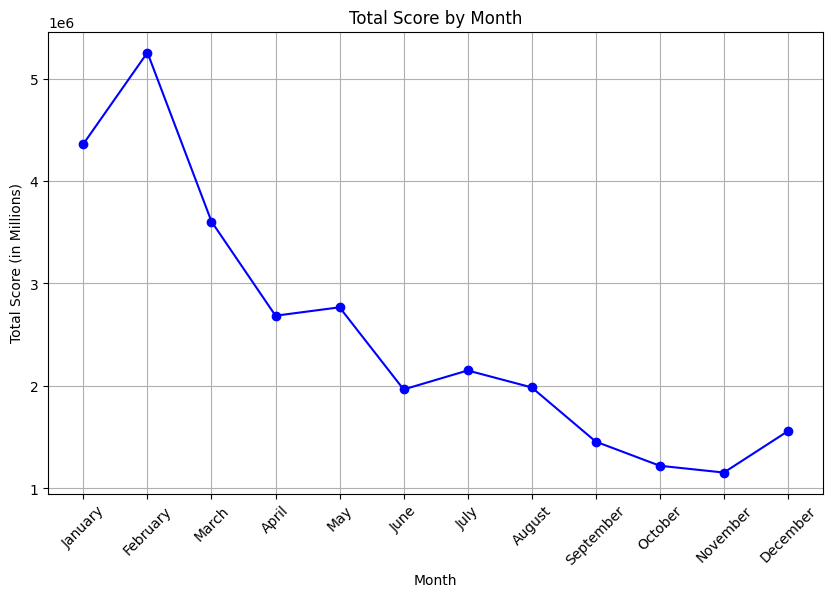

In [41]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(monthly_total_score.index, monthly_total_score.values, marker='o', color='b', linestyle='-')
plt.xlabel('Month')
plt.ylabel('Total Score (in Millions)')
plt.title('Total Score by Month')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

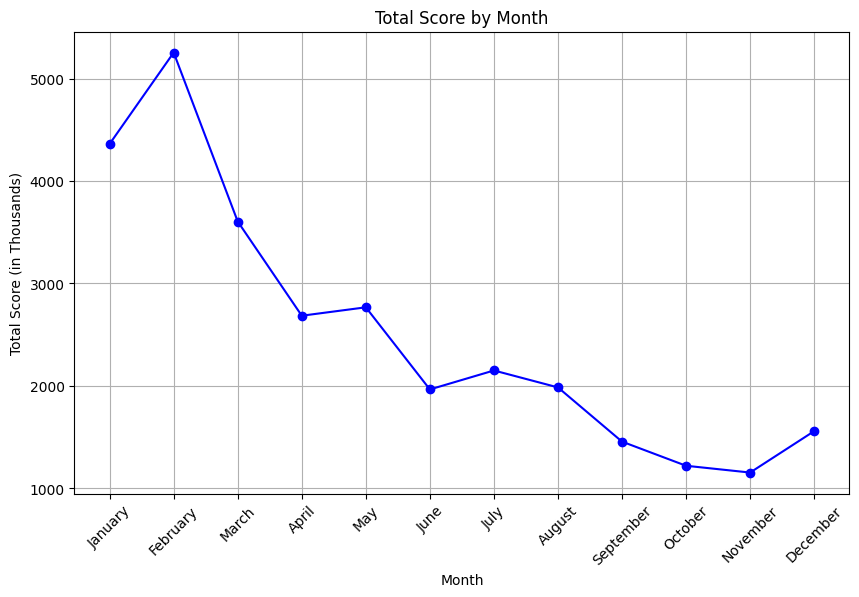

In [42]:
# Scale down the total score values (to thousands)
monthly_total_score_thousands = monthly_total_score / 1000

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(monthly_total_score_thousands.index, monthly_total_score_thousands.values, marker='o', color='b', linestyle='-')
plt.xlabel('Month')
plt.ylabel('Total Score (in Thousands)')
plt.title('Total Score by Month')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Player activity by day of the week: which day or days are players most active?**

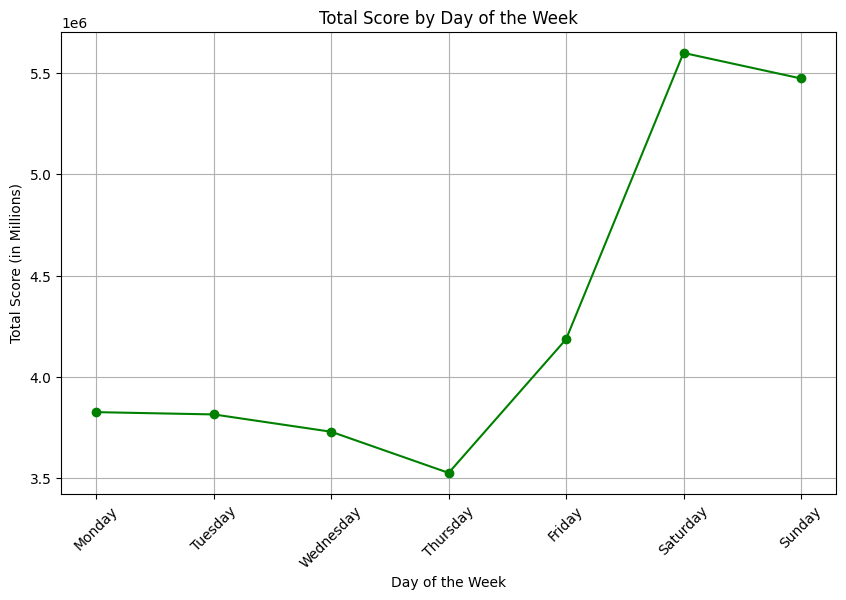

In [43]:
# Extract day of the week from 'date' column
df['day_of_week'] = pd.to_datetime(df['date']).dt.day_name()

# Define order for days of the week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=days_order, ordered=True)

# Total score by day of the week
daily_total_score = df.groupby('day_of_week', observed=True)['score'].sum()

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(daily_total_score.index, daily_total_score.values, marker='o', color='g', linestyle='-')
plt.xlabel('Day of the Week')
plt.ylabel('Total Score (in Millions)')
plt.title('Total Score by Day of the Week')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Player activity by hour of the day: when / at what hour are players most active?**

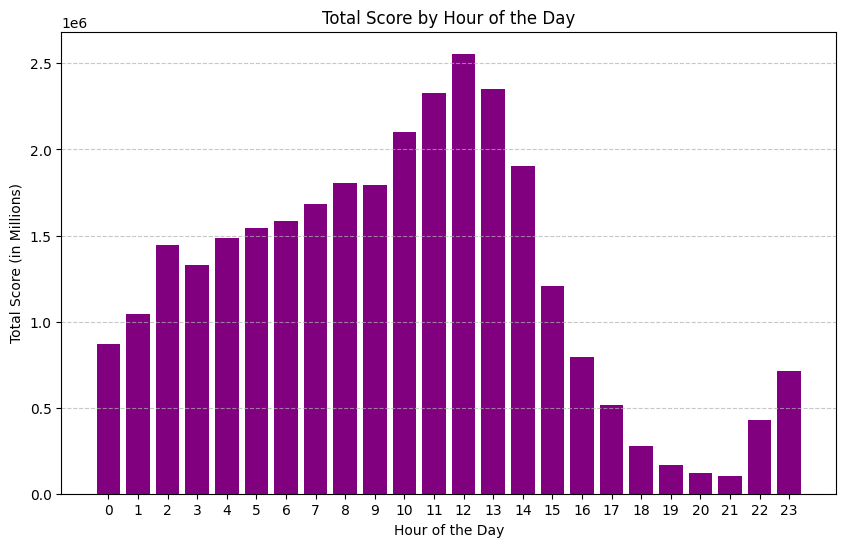

In [46]:
# Extract hour from 'time_hr'
df['hour_of_day'] = pd.to_datetime(df['time_hr'], format='%H:%M:%S').dt.hour

# Calculate total score by hour of the day
hourly_total_score = df.groupby('hour_of_day')['score'].sum()

# Plot the data
plt.figure(figsize=(10, 6))
plt.bar(hourly_total_score.index, hourly_total_score.values, color='purple')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Score (in Millions)')
plt.title('Total Score by Hour of the Day')
plt.xticks(range(0, 24))  # ensures every hour is shown on the x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Note: here you can experiment with plotting score by hour of the day for a different timezone


In [47]:
# Convert to dataframe for better readability
hourly_score_table = hourly_total_score.reset_index()
hourly_score_table.columns = ['Hour of Day', 'Total Score']

# Display the table
print(hourly_score_table)

    Hour of Day  Total Score
0             0       869513
1             1      1044581
2             2      1442811
3             3      1327965
4             4      1485278
5             5      1543459
6             6      1585783
7             7      1681935
8             8      1806139
9             9      1796245
10           10      2100756
11           11      2328721
12           12      2556152
13           13      2352734
14           14      1904551
15           15      1206958
16           16       794222
17           17       517019
18           18       279680
19           19       167552
20           20       120680
21           21       104191
22           22       430076
23           23       710088


**Explore 'score' variable**

In [ ]:
# Describe 'score'
print("Summary statistics of the 'score' variable:")
display(df['score'].describe())

Summary statistics of the 'score' variable:


,score
count,153920.000000
mean,195.927034
std,443.620259
min,0.000000
25%,20.000000
50%,72.000000
75%,205.000000
max,20964.000000


In [ ]:
# What does it mean that the mean and the median are far away?

In [48]:
# Median value of 'score'
print("Median of 'score':", df['score'].median())

Median of 'score': 72.0


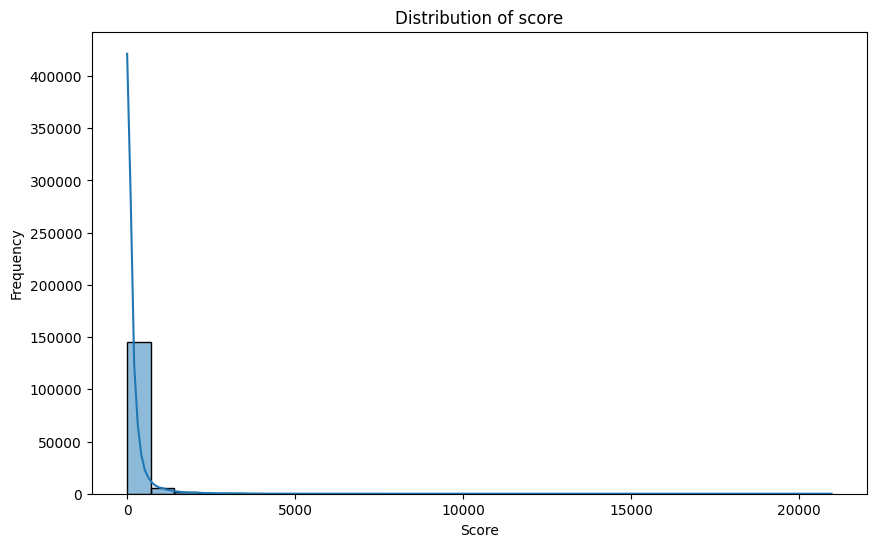

In [49]:
# Plot the distribution of 'score' variable
plt.figure(figsize=(10, 6))
sns.histplot(df['score'], kde=True, bins=30)
plt.title('Distribution of score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

**Player score variability**

In [50]:
# Score variability for each player

# Calculate score standard deviation per player
score_variability = df.groupby('device')['score'].std().reset_index()

# Rename columns
score_variability.columns = ['player_id', 'score_std_dev']

# Check if it's correct
print(score_variability.head())

#What does NaN mean in this case? (hint: some players played only once)

         player_id  score_std_dev
0                0      98.969271
1  000000000000000     398.282132
2  010941525590041            NaN
3  012345678901237       0.707107
4  012345678912345     842.582951


In [51]:
# Summary statistics of player score variability
print("\nSummary statistics of score variability:")
print(score_variability['score_std_dev'].describe())


Summary statistics of score variability:
count    14534.000000
mean       167.230254
std        354.086570
min          0.000000
25%         26.870058
50%         64.298478
75%        154.261945
max       9060.710513
Name: score_std_dev, dtype: float64


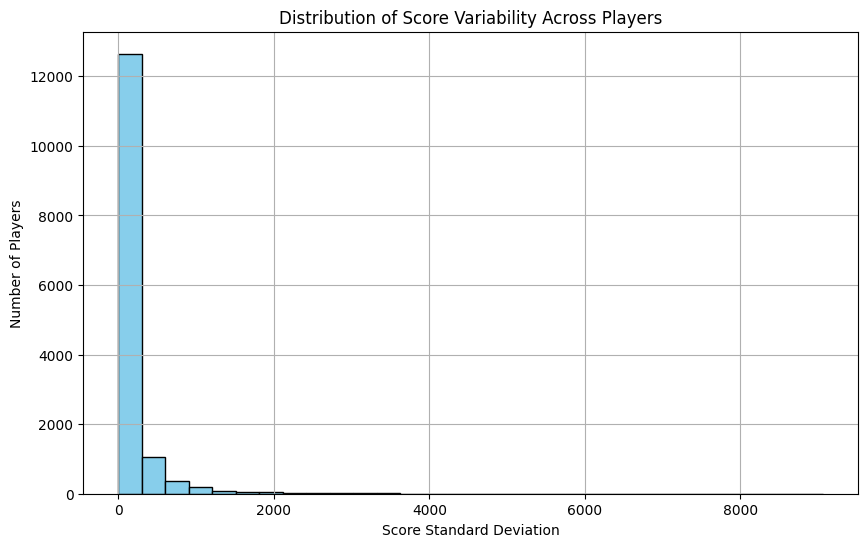

In [52]:
# Plot distribution of score variability
plt.figure(figsize=(10, 6))
plt.hist(score_variability['score_std_dev'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Score Standard Deviation')
plt.ylabel('Number of Players')
plt.title('Distribution of Score Variability Across Players')
plt.grid(True)
plt.show()

In [53]:
# Identify players with very high or very low score variability
high_variability = score_variability[score_variability['score_std_dev'] > score_variability['score_std_dev'].quantile(0.75)]
low_variability = score_variability[score_variability['score_std_dev'] < score_variability['score_std_dev'].quantile(0.25)]

print("\nPlayers with high score variability (top 25%):")
print(high_variability)

print("\nPlayers with low score variability (bottom 25%):")
print(low_variability)


Players with high score variability (top 25%):
             player_id  score_std_dev
1      000000000000000     398.282132
4      012345678912345     842.582951
13     013703000737787     413.682418
18     014097008062978     253.374888
47     351508060116685     161.927453
...                ...            ...
25708   A000002F82D51D     178.617188
25727   A000002F857DD0     277.499910
25753   A00000312BCF53     164.688135
25822   A1000019612ACD     241.726636
25884   a00000088b0c80     253.263697

[3634 rows x 2 columns]

Players with low score variability (bottom 25%):
             player_id  score_std_dev
3      012345678901237       0.707107
6      012403004537025       9.464847
10     013460002038033      10.606602
11     013689004460635       7.229651
14     014035001426733      13.892444
...                ...            ...
25935   a0000008bd1188       9.643651
25936   a0000008bd18c7      16.238455
25940   a0000008bea733      12.727922
25944   a0000037802dc2       7.681146
259

In [54]:
# Check number of players with a single score
single_score_players = df.groupby('device')['score'].count()
single_score_players = single_score_players[single_score_players == 1]
print("Number of players with only one score:", len(single_score_players))


Number of players with only one score: 11422


**One-session and multi-session players**

In [55]:
# Count the number of sessions per unique device (player)
session_counts = df.groupby('device').size().reset_index(name='session_count')

In [56]:
# Label players based on their session count as one-session or multi-session
session_counts['session_label'] = session_counts['session_count'].apply(lambda x: 'one-session' if x == 1 else 'multi-session')

In [57]:
# Assign 1 to players who played at least 10 times
session_counts['played_10_plus'] = (session_counts['session_count'] >= 10).astype(int)

In [58]:
# Inspect to check that it's correct
print(session_counts.head())
print(session_counts.columns)


            device  session_count  session_label  played_10_plus
0                0              4  multi-session               0
1  000000000000000             40  multi-session               1
2  010941525590041              1    one-session               0
3  012345678901237              2  multi-session               0
4  012345678912345           1618  multi-session               1
Index(['device', 'session_count', 'session_label', 'played_10_plus'], dtype='object')


In [59]:
# Show counts of each label to verify
#how many players played one-session vs multiple and players who played less than 10 times vs > 10 times
print(session_counts['session_label'].value_counts())
print(session_counts['played_10_plus'].value_counts())


session_label
multi-session    14534
one-session      11422
Name: count, dtype: int64
played_10_plus
0    23093
1     2863
Name: count, dtype: int64


In [60]:
# Merge session_counts back to the original dataframe
df = df.merge(session_counts[['device', 'session_count', 'session_label', 'played_10_plus']], on='device', how='left')

In [61]:
df.head()

,device,score,time,converted_time,date,time_hr,month,month_cat,day_of_week,hour_of_day,session_count,session_label,played_10_plus
0,352610060979119,7,1421157320,2015-01-13 13:55:20,2015-01-13,13:55:20,January,January,Tuesday,13,4,multi-session,0
1,352610060979119,0,1421157288,2015-01-13 13:54:48,2015-01-13,13:54:48,January,January,Tuesday,13,4,multi-session,0
2,352610060979119,6,1421157344,2015-01-13 13:55:44,2015-01-13,13:55:44,January,January,Tuesday,13,4,multi-session,0
3,99000072289368,106,1421163166,2015-01-13 15:32:46,2015-01-13,15:32:46,January,January,Tuesday,15,2,multi-session,0
4,357470044931974,278,1421163783,2015-01-13 15:43:03,2015-01-13,15:43:03,January,January,Tuesday,15,910,multi-session,1


**OP and CP periods**

In [ ]:
# Define OP and CP length
# Find each players t0
# Go through each player and count their plays in OP and CP
# Create churn status: players who have plays in both OP and CP periods are assigned 0 ('no churn'), otherwise they are assigned 1 ('churn')
# Check churn status distribution; what is the proportion of churners vs non-churners? How do differently set OPs and CPs change this distribution?
# Engineer features based on OP period only
# What are the implications of the features engineered based on variance or standard deviation across sessions?